In [29]:
!pip install librosa openai-whisper tensorflow scikit-learn matplotlib seaborn # for text processing

In [30]:
# all necessary libraries

import os
import glob
import librosa
import whisper
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    Embedding,
    LSTM
)

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [31]:
from google.colab import drive
drive.mount('/content/drive')

dataset_path = "/content/drive/MyDrive/RAVDESS"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
#emotions mapping
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

Classification based on Audio files which are Converted into Mel spectograms and then using CNN

In [33]:
#Load Audio File Paths and Labels

files = glob.glob(dataset_path + "/*/*.wav")

paths = []
labels = []

for file in files:

    filename = os.path.basename(file)
    emotion_code = filename.split("-")[2]
    emotion = emotion_map[emotion_code]
    paths.append(file)
    labels.append(emotion)

print("Total files:", len(paths))

Total files: 416


In [34]:
#Mel Spectrograms generation
X_audio = []

for path in paths:

    audio, sr = librosa.load(path, sr=22050)
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128
    )

    mel_db = librosa.power_to_db(mel)

    # Fix width to 128
    mel_db = mel_db[:, :128]

    if mel_db.shape[1] < 128:

        pad_width = 128 - mel_db.shape[1]

        mel_db = np.pad(
            mel_db,
            pad_width=((0, 0), (0, pad_width))
        )

    X_audio.append(mel_db)

X_audio = np.array(X_audio)

print(X_audio.shape)

(416, 128, 128)


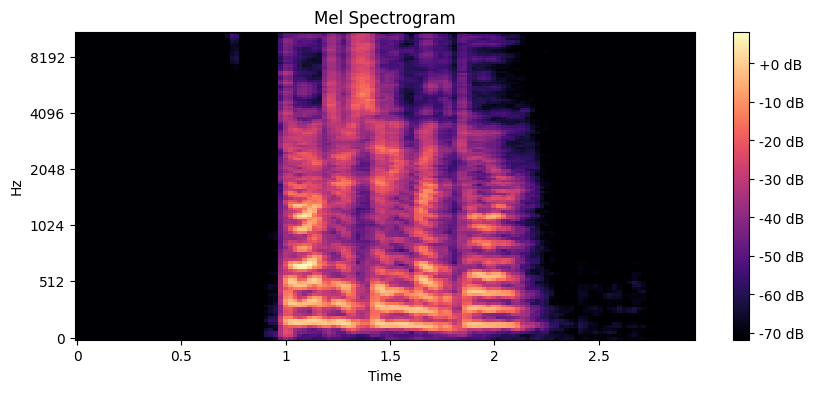

In [35]:
#visualizing them
plt.figure(figsize=(10, 4))

librosa.display.specshow(
    X_audio[0],
    x_axis='time',
    y_axis='mel'
)

plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")
plt.show()

In [36]:
X_audio = X_audio[..., np.newaxis] # reshaping for CNN
print(X_audio.shape)

(416, 128, 128, 1)


In [37]:
le = LabelEncoder()
y = le.fit_transform(labels)
y = to_categorical(y)

print(y.shape)

(416, 8)


In [38]:
#Train Test Splitting
X_train_audio, X_test_audio, y_train, y_test = train_test_split(
    X_audio,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
#Building  CNN Model

audio_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)),
    MaxPooling2D((2,2)),

    Conv2D( 64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D( 128, (3,3),activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.3),

    Dense(8, activation='softmax')
])

audio_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

audio_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,096 (12.61 MB)

 Trainable params: 3,305,096 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
#Train CNN Model

history_audio = audio_model.fit(
    X_train_audio,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 364ms/step - accuracy: 0.1736 - loss: 12.9408 - val_accuracy: 0.1343 - val_loss: 2.1526
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2000 - loss: 2.0881 - val_accuracy: 0.1642 - val_loss: 2.2029
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2642 - loss: 1.9216 - val_accuracy: 0.2836 - val_loss: 1.9068
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3094 - loss: 1.8139 - val_accuracy: 0.2687 - val_loss: 1.8047
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3962 - loss: 1.7123 - val_accuracy: 0.2836 - val_loss: 1.7192
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4189 - loss: 1.5056 - val_accuracy: 0.2985 - val_loss: 1.7403
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4453 - loss: 1.4861 - val_accuracy: 0.2836 - val_loss: 1.7265
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5094 - loss: 1.3614 - val_accuracy: 0.3433 - val_loss: 1.72

In [41]:
#Evaluation

audio_loss, audio_acc = audio_model.evaluate(
    X_test_audio,
    y_test
)

print("Audio Model Accuracy:", audio_acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 331ms/step - accuracy: 0.4643 - loss: 2.1899
Audio Model Accuracy: 0.4642857015132904


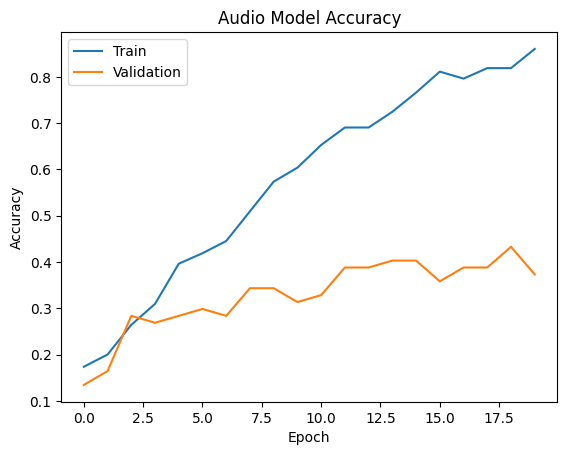

In [42]:
#Plotting Training Graphs
plt.plot(history_audio.history['accuracy'])
plt.plot(history_audio.history['val_accuracy'])

plt.title("Audio Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 270ms/step


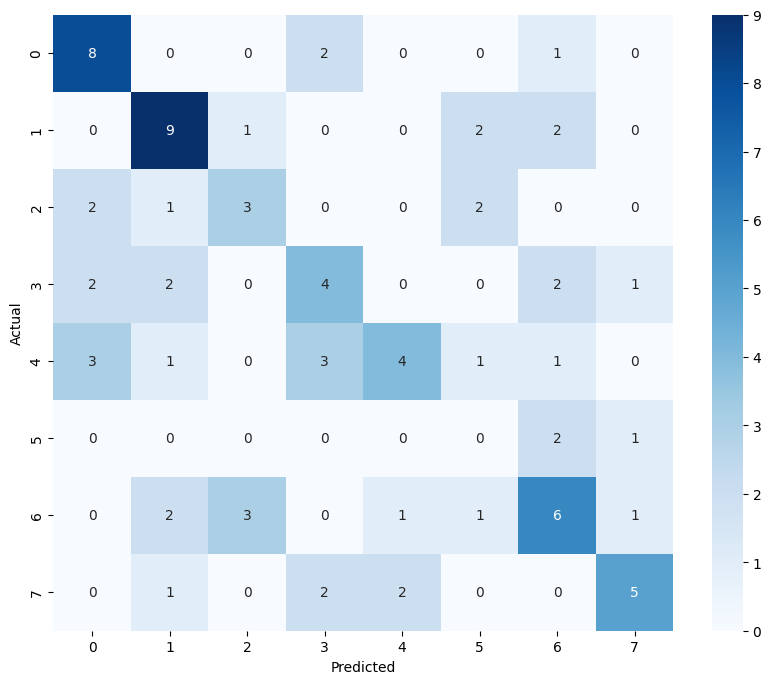

In [43]:
#Confusion Matrix for CNN

pred_audio = audio_model.predict(X_test_audio)
pred_audio = np.argmax(pred_audio, axis=1)

true_audio = np.argmax(y_test, axis=1)

cm = confusion_matrix(true_audio, pred_audio)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [44]:
#Classification Report
print(classification_report(
    true_audio,
    pred_audio,
    target_names=le.classes_
))

              precision    recall  f1-score   support

       angry       0.53      0.73      0.62        11
        calm       0.56      0.64      0.60        14
     disgust       0.43      0.38      0.40         8
     fearful       0.36      0.36      0.36        11
       happy       0.57      0.31      0.40        13
     neutral       0.00      0.00      0.00         3
         sad       0.43      0.43      0.43        14
   surprised       0.62      0.50      0.56        10

    accuracy                           0.46        84
   macro avg       0.44      0.42      0.42        84
weighted avg       0.49      0.46      0.47        84



Text Classification using whisper flow from open-AI

In [45]:
#loading whisper flow
whisper_model = whisper.load_model("base")

In [46]:
#Generate Text Transcripts
texts = []

for path in paths:

    result = whisper_model.transcribe(path)

    text = result["text"]


    texts.append(text)

print(texts[:5])


#Tokenisation
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

X_text = pad_sequences(
    sequences,
    maxlen=50
)

print(X_text.shape)

[' Dogs are sitting by the door.', ' Kids are talking by the door!', ' Kids are talking by the door.', ' Dogs are sitting by the door.', ' Dogs are sitting by the door.']
(416, 50)


In [47]:
#Train test split for the text
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42
)

In [48]:
#LTSM MOdel
text_model = Sequential([

    Embedding(input_dim=5000, output_dim=128,input_length=50),
    LSTM(128),

    Dense(64, activation='relu'),

    Dropout(0.3),

    Dense(8, activation='softmax')
])

text_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

text_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [49]:
#Training  Model
history_text = text_model.fit(
    X_train_text,
    y_train_text,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.1585 - loss: 2.0786 - val_accuracy: 0.1194 - val_loss: 2.0780
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1245 - loss: 2.0758 - val_accuracy: 0.1343 - val_loss: 2.0785
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1057 - loss: 2.0763 - val_accuracy: 0.1045 - val_loss: 2.0809
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1811 - loss: 2.0662 - val_accuracy: 0.1791 - val_loss: 2.0771
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1472 - loss: 2.0673 - val_accuracy: 0.1791 - val_loss: 2.0813
Epoch 6/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1245 - loss: 2.0721 - val_accuracy: 0.1791 - val_loss: 2.0832
Epoch 7/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1396 - loss: 2.0740 - val_accuracy: 0.0448 - val_loss: 2.0785
Epoch 8/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1585 - loss: 2.0697 - val_accuracy: 0.0896 - val_loss: 2.0780


In [50]:
#Evaluate Text Model
text_loss, text_acc = text_model.evaluate(
    X_test_text,
    y_test_text
)

print("Text Model Accuracy:", text_acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1548 - loss: 2.0478
Text Model Accuracy: 0.1547619104385376


Fusioning the features from 2 models

In [51]:
#text
text_feature_model = Model(
    inputs=text_model.layers[0].input,
    outputs=text_model.layers[-2].output
)

text_features = text_feature_model.predict(X_text)

print(text_features.shape)

#audio
audio_feature_model = Model(
    inputs=audio_model.layers[0].input,
    outputs=audio_model.layers[-2].output
)

audio_features = audio_feature_model.predict(X_audio)

print(audio_features.shape)

#Concatination
fusion_features = np.concatenate(
    [audio_features, text_features],
    axis=1
)

print(fusion_features.shape)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
(416, 64)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
(416, 128)
(416, 192)


In [52]:
#Train test split for fusion
X_train_fusion, X_test_fusion, y_train_fusion, y_test_fusion = train_test_split(
    fusion_features,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
#fusion model
fusion_model = Sequential([

    Dense(
        128,
        activation='relu',
        input_shape=(fusion_features.shape[1],)
    ),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(8, activation='softmax')
])

fusion_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fusion_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,480 (130.78 KB)

 Trainable params: 33,480 (130.78 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
#training and evaluation
history_fusion = fusion_model.fit(
    X_train_fusion,
    y_train_fusion,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

history_fusion = fusion_model.fit(
    X_train_fusion,
    y_train_fusion,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)


fusion_loss, fusion_acc = fusion_model.evaluate(
    X_test_fusion,
    y_test_fusion
)

print("Fusion Model Accuracy:", fusion_acc)


Epoch 1/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 207ms/step - accuracy: 0.1283 - loss: 2.8050 - val_accuracy: 0.2090 - val_loss: 1.8245
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3811 - loss: 1.6203 - val_accuracy: 0.3134 - val_loss: 1.6599
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5698 - loss: 1.2750 - val_accuracy: 0.3582 - val_loss: 1.5534
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6755 - loss: 1.0500 - val_accuracy: 0.3881 - val_loss: 1.5358
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7509 - loss: 0.8612 - val_accuracy: 0.3731 - val_loss: 1.5639
Epoch 6/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7887 - loss: 0.7642 - val_accuracy: 0.3731 - val_loss: 1.6153
Epoch 7/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7887 - loss: 0.6612 - val_accuracy: 0.4179 - val_loss: 1.6211
Epoch 8/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8340 - loss: 0.5442 - val_accuracy: 0.3881 - val_loss: 1.6469

In [55]:
#comparing results
print("Audio Model Accuracy :", audio_acc)
print("Text Model Accuracy  :", text_acc)
print("Fusion Model Accuracy:", fusion_acc)

Audio Model Accuracy : 0.4642857015132904
Text Model Accuracy  : 0.1547619104385376
Fusion Model Accuracy: 0.5357142686843872
